## **Connect Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Import Libraries**

In [ ]:
!pip install transformers datasets tqdm scikit-learn sentencepiece -q

In [ ]:
import re
import json
import os
import itertools
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer
from tqdm.auto import tqdm

## **Setup: Path, Configuration, Constant**

In [ ]:
BASE_DIR         = '/content/drive/MyDrive/Colab Datasets'
SPLIT_DIR        = f'{BASE_DIR}/Split Data'
BIO_DIR          = f'{BASE_DIR}/BIO Splits v2'
BIO_DIR_OLD      = f'{BASE_DIR}/BIO Splits'

MODEL_NAME       = 'bigscience/bloom-560m'
LOCAL_BLOOM_PATH = f'{BASE_DIR}/bloom-560m-local'
MAX_LENGTH       = 512
IGNORE_IDX       = -100

# Per-language percentile untuk build lexicon
LANG_PERCENTILE = {
    'id': 85,
    'en': 85,
    'mixed': 88,
}

# Mapping label BIO (format numerik konsisten dengan NB03/NB04/NB05)
# 0=O, 1=B-TOX, 2=I-TOX, -100=IGNORE (padding/special tokens)
LABEL2ID = {'O': 0, 'B-TOX': 1, 'I-TOX': 2}
ID2LABEL = {0: 'O', 1: 'B-TOX', 2: 'I-TOX'}

os.makedirs(BIO_DIR, exist_ok=True)

print(f'📁 OUTPUT → {BIO_DIR}')
print(f'📁 INPUT  ← {SPLIT_DIR}')
print(f'📁 LAMA   ← {BIO_DIR_OLD} (referensi)')
print(f'🔧 MAX_LENGTH     = {MAX_LENGTH}')
print(f'🔧 IGNORE_IDX     = {IGNORE_IDX}')
print(f'🔧 LANG_PERCENTILE= {LANG_PERCENTILE}')

📁 OUTPUT → /content/drive/MyDrive/Colab Datasets/BIO Splits v2
📁 INPUT  ← /content/drive/MyDrive/Colab Datasets/Split Data
📁 LAMA   ← /content/drive/MyDrive/Colab Datasets/BIO Splits (referensi)
🔧 MAX_LENGTH     = 512
🔧 IGNORE_IDX     = -100
🔧 LANG_PERCENTILE= {'id': 85, 'en': 85, 'mixed': 88}


## **Define clean_for_tfidf**

In [ ]:
import re as _re_tfidf

def clean_for_tfidf(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = _re_tfidf.sub(r'[^a-z0-9 ]', '', text)
    text = _re_tfidf.sub(r'([a-z])\1{2,}', r'\1\1', text)
    text = _re_tfidf.sub(r'\s+', ' ', text).strip()
    return text

# Sanity check
print('Sanity check clean_for_tfidf:')
tests = [
    ('Anjing!',         'anjing'),
    ('BANGSAT...',      'bangsat'),
    ("it's ok",         'its ok'),
    ('4nj1ng',          '4nj1ng'),
    ('hello  world!',   'hello world'),
    ('otak  tempurung', 'otak tempurung'),
    ('anjiiiing',       'anjiing'),
    ('goobloook',       'gooblook'),
]
all_ok = True
for raw, expected in tests:
    result = clean_for_tfidf(raw)
    ok = result == expected
    status = '✅' if ok else '❌'
    print(f'  {status}  clean("{raw}") → "{result}" (expected: "{expected}")')
    if not ok:
        all_ok = False
if all_ok:
    print('\n✅ Semua test PASS.')
else:
    print('\n❌ Ada test FAIL!')

Sanity check clean_for_tfidf:
  ✅  clean("Anjing!") → "anjing" (expected: "anjing")
  ✅  clean("BANGSAT...") → "bangsat" (expected: "bangsat")
  ✅  clean("it's ok") → "its ok" (expected: "its ok")
  ✅  clean("4nj1ng") → "4nj1ng" (expected: "4nj1ng")
  ✅  clean("hello  world!") → "hello world" (expected: "hello world")
  ✅  clean("otak  tempurung") → "otak tempurung" (expected: "otak tempurung")
  ✅  clean("anjiiiing") → "anjiing" (expected: "anjiing")
  ✅  clean("goobloook") → "gooblook" (expected: "gooblook")

✅ Semua test PASS.


## **Load Tokenizer BLOOM-560m**

In [ ]:
import shutil

if os.path.exists(LOCAL_BLOOM_PATH):
    try:
        tokenizer = AutoTokenizer.from_pretrained(LOCAL_BLOOM_PATH, use_fast=True)
        print(f'✅ Tokenizer dimuat dari lokal: {LOCAL_BLOOM_PATH}')
    except (ValueError, OSError) as e:
        # Local cache rusak/tidak lengkap → hapus & re-download
        print(f'⚠️ Local tokenizer error: {e}')
        print(f'🗑️ Menghapus local cache dan re-download...')
        shutil.rmtree(LOCAL_BLOOM_PATH)
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
        tokenizer.save_pretrained(LOCAL_BLOOM_PATH)   # ← fix: 'tokenizer', bukan 'fast_tok'
        print(f'✅ Tokenizer diunduh & disimpan ke: {LOCAL_BLOOM_PATH}')
else:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    tokenizer.save_pretrained(LOCAL_BLOOM_PATH)       # ← fix: 'tokenizer', bukan 'fast_tok'
    print(f'✅ Tokenizer dimuat dari HuggingFace Hub: {MODEL_NAME}')

tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'right'

print(f'   Vocab size  : {tokenizer.vocab_size:,}')
print(f'   Pad token   : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})')
print(f'   Padding side: {tokenizer.padding_side}')
print(f'   Model max   : {tokenizer.model_max_length}')

✅ Tokenizer dimuat dari lokal: /content/drive/MyDrive/Colab Datasets/bloom-560m-local
   Vocab size  : 250,680
   Pad token   : '</s>' (id=2)
   Padding side: right
   Model max   : 1000000000000000019884624838656


## **Load Split Data**

In [ ]:
df_train = pd.read_csv(f'{SPLIT_DIR}/train.csv')
df_val   = pd.read_csv(f'{SPLIT_DIR}/val.csv')
df_test  = pd.read_csv(f'{SPLIT_DIR}/test.csv')

print(f'Train : {len(df_train):>6,} baris   Kolom: {df_train.columns.tolist()}')
print(f'Val   : {len(df_val):>6,} baris')
print(f'Test  : {len(df_test):>6,} baris')

REQUIRED_INPUT_COLS = ['text', 'label', 'language']
OPTIONAL_COLS       = ['has_slang', 'has_abbrev']
for col in REQUIRED_INPUT_COLS:
    assert col in df_train.columns, f'MISSING kolom wajib: {col}'
for col in OPTIONAL_COLS:
    if col not in df_train.columns:
        print(f'  ⚠️  Kolom {col!r} tidak ada di NB01 output — akan ditambahkan default 0')
        for df in [df_train, df_val, df_test]:
            df[col] = 0
    else:
        print(f'  ✅ Kolom {col!r} tersedia')

Train : 28,000 baris   Kolom: ['id', 'text', 'label', 'language', 'has_slang', 'has_abbrev', 'source']
Val   :  6,000 baris
Test  :  6,000 baris
  ✅ Kolom 'has_slang' tersedia
  ✅ Kolom 'has_abbrev' tersedia


## **Check Split Distribution**

In [ ]:
THRESHOLD = 5.0

def check_distribution(datasets: dict, col_name: str):
    props = {}
    for name, df in datasets.items():
        if col_name not in df.columns:
            print(f'  ⚠️  Kolom {col_name!r} tidak ada di {name}, skip.')
            continue
        counts = df[col_name].value_counts(normalize=True).sort_index()
        props[name] = (counts * 100).to_dict()

    all_values = sorted(set().union(*[p.keys() for p in props.values()]))
    print(f"\n{'='*55}")
    print(f'Kolom: {col_name}  |  Max selisih threshold: {THRESHOLD}%')
    print(f"{'Nilai':<8} {'Train':>10} {'Val':>10} {'Test':>10}")
    print('-' * 42)
    max_diff = 0
    for val in all_values:
        train_p = props['train'].get(val, 0.0)
        val_p   = props['val'].get(val, 0.0)
        test_p  = props['test'].get(val, 0.0)
        print(f'{val:<8} {train_p:>9.2f}% {val_p:>9.2f}% {test_p:>9.2f}%')
        diff = max(train_p, val_p, test_p) - min(train_p, val_p, test_p)
        if diff > max_diff:
            max_diff = diff
    print('-' * 42)
    print(f'Selisih maksimum: {max_diff:.2f}%')
    if max_diff <= THRESHOLD:
        print('✅ Distribusi RATA (perbedaan ≤ 5%)')
    else:
        print('⚠️  Distribusi TIDAK RATA (perbedaan > 5%)')

splits = {'train': df_train, 'val': df_val, 'test': df_test}
for col in ['label', 'language', 'has_slang', 'has_abbrev']:
    check_distribution(splits, col)


Kolom: label  |  Max selisih threshold: 5.0%
Nilai         Train        Val       Test
------------------------------------------
0            50.00%     50.00%     50.02%
1            50.00%     50.00%     49.98%
------------------------------------------
Selisih maksimum: 0.02%
✅ Distribusi RATA (perbedaan ≤ 5%)

Kolom: language  |  Max selisih threshold: 5.0%
Nilai         Train        Val       Test
------------------------------------------
en           30.00%     30.00%     30.00%
id           29.49%     29.48%     29.47%
mixed        40.51%     40.52%     40.53%
------------------------------------------
Selisih maksimum: 0.02%
✅ Distribusi RATA (perbedaan ≤ 5%)

Kolom: has_slang  |  Max selisih threshold: 5.0%
Nilai         Train        Val       Test
------------------------------------------
0            68.49%     68.45%     68.48%
1            31.51%     31.55%     31.52%
------------------------------------------
Selisih maksimum: 0.04%
✅ Distribusi RATA (perbedaan ≤ 5%)


## **Check Missing Values**

In [ ]:
def check_nan(df: pd.DataFrame, name: str):
    print(f"\n{'═'*55}")
    print(f' NaN Check — {name.upper()}')
    print(f"{'═'*55}")
    total_missing = df.isnull().sum().sum()
    missing_per_col = df.isnull().sum()
    missing_pct     = (missing_per_col / len(df) * 100).round(2)
    for col in df.columns:
        n   = missing_per_col[col]
        pct = missing_pct[col]
        status = '⚠️ ' if n > 0 else '✅'
        print(f'  {status} {col:<20} {n:>6} missing  ({pct:.2f}%)')
    print('-' * 55)
    if total_missing > 0:
        print(f'  ⚠️  Total missing: {total_missing}')
        if 'text' in df.columns:
            df['text'] = df['text'].fillna('')
            print(f'  → text: di-fillna string kosong.')
        if 'label' in df.columns and df['label'].isnull().any():
            df['label'] = df['label'].fillna(0).astype(int)
            print(f'  ⚠️  label: di-fillna 0 (NON-HATE) — periksa data NB01!')
        if 'language' in df.columns and df['language'].isnull().any():
            df['language'] = df['language'].fillna('mixed')
            print(f'  ⚠️  language: di-fillna "mixed" — periksa data NB01!')
    else:
        print('  ✅ Tidak ada missing value.')

check_nan(df_train, 'train')
check_nan(df_val,   'val')
check_nan(df_test,  'test')


═══════════════════════════════════════════════════════
 NaN Check — TRAIN
═══════════════════════════════════════════════════════
  ✅ id                        0 missing  (0.00%)
  ✅ text                      0 missing  (0.00%)
  ✅ label                     0 missing  (0.00%)
  ✅ language                  0 missing  (0.00%)
  ✅ has_slang                 0 missing  (0.00%)
  ✅ has_abbrev                0 missing  (0.00%)
  ✅ source                    0 missing  (0.00%)
-------------------------------------------------------
  ✅ Tidak ada missing value.

═══════════════════════════════════════════════════════
 NaN Check — VAL
═══════════════════════════════════════════════════════
  ✅ id                        0 missing  (0.00%)
  ✅ text                      0 missing  (0.00%)
  ✅ label                     0 missing  (0.00%)
  ✅ language                  0 missing  (0.00%)
  ✅ has_slang                 0 missing  (0.00%)
  ✅ has_abbrev                0 missing  (0.00%)
  ✅ source      

## **Build Differential Lexicon (Bigram + Per-Language Percentile)**

In [ ]:
STOPWORDS_ID = {
    'saya','aku','kamu','anda','dia','ia','mereka','kita','kami','kalian','beliau',
    'gue','gua','gw','lo','lu','loe','elu',
    'yang','dan','di','ke','dari','ini','itu','dengan','untuk','pada','adalah',
    'atau','juga','oleh','bagi','atas','dalam','antara','terhadap','tentang',
    'menurut','seperti','karena','karna','sebab','sehingga','agar','supaya',
    'bahwa','apabila','jika','bila','kalau','kalo','walaupun','meskipun','meski',
    'padahal','namun','tetapi','tapi','melainkan','sedangkan','serta','lalu',
    'kemudian','setelah','sebelum','ketika','saat','selama',
    'sudah','telah','akan','sedang','lagi','masih','belum','blm','udah','udh',
    'pernah','sempat','tidak','gak','ga','ngga','nggak','enggak','kagak','bukan',
    'jangan','cukup','sangat','banget','bgt','sekali','amat','sungguh','paling',
    'lebih','sedikit','banyak','hanya','saja','aja','kok','malah','justru',
    'bahkan','hampir','langsung','ada','bisa','dapat','mampu','boleh','harus',
    'perlu','ingin','mau','hendak','jadi','menjadi','bilang','ngomong','omong',
    'kasih','beri','berikan','buat','bikin','minta','tanya','jawab','lihat',
    'liat','denger','dengar','tau','tahu','sekarang','kini','dulu','nanti','tadi',
    'besok','kemarin','hari','malam','pagi','siang','sore','waktu','tahun',
    'bulan','minggu','semua','seluruh','setiap','tiap','beberapa',
    'satu','dua','tiga','empat','lima','jadi','terus','trus','abis','habis',
    'nih','sih','deh','dong','kan','tuh','lah','emang','memang','pun','yg',
    'eh','ah','ih','oh','uh','wah','yah','yaah','loh','lho','woi','oi',
    'iya','iye','oke','ok','ya','yaa','yup','yep','nah','nope',
}
STOPWORDS_EN = {
    'i','me','my','myself','you','your','yourself','yourselves',
    'he','him','his','himself','she','her','hers','herself',
    'it','its','itself','we','us','our','ours','ourselves',
    'they','them','their','theirs','themselves',
    'this','that','these','those','who','whom','whose','which',
    'what','where','when','why','how','a','an','the',
    'in','on','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from',
    'up','down','of','off','over','under','around','onto','upon',
    'within','without','across','along','among','beside','beyond','near',
    'and','but','or','nor','yet','so','although','because','since',
    'while','unless','until','though','even','whether','as','if','than','then',
    'be','been','being','is','are','was','were','am',
    'have','has','had','having','do','does','did','doing',
    'will','would','could','should','may','might','shall','can',
    'not','no','never','always','often','sometimes','usually','already',
    'still','just','only','even','also','too','very','really','quite',
    'rather','pretty','actually','however','therefore','otherwise',
    'meanwhile','instead','again','back','away','here','there','now',
    'then','soon','well','right','enough',
    'all','any','both','each','every','either','neither','many','much',
    'few','little','more','most','less','least','some','other','another',
    'such','same','different','own','half','next','last','first',
    'one','two','several','certain','people','person','folk','folks',
    'ones','others','thing','things','way','ways','time','times',
    'day','days','year','years','place','places','part','parts',
    'case','point','fact','world','country','nation','society','media',
    'government','life','lives','hand','hands','eye','eyes',
    'new','high','low','big','small','large','great','long','short',
    'early','young','real','true','free','able','sure','ready',
    'hard','easy','important','possible','clear','bet','okay',
}
BLOCKLIST_TOKENS = {
    'user','url','link','rt','via','amp','gt','lt','hashtag','trending',
    'viral','repost','share','dm','pm','ig','fb','yt',
    "i'm","i've","i'd","i'll","you're","you've","you'd","you'll",
    "he's","she's","it's","we're","they're",
    "don't","won't","can't","didn't","doesn't","isn't","aren't","wasn't","weren't",
    'http','https','www','com'
}

LEXICON_STOPWORDS = STOPWORDS_ID | STOPWORDS_EN
GLOBAL_BLOCKLIST = STOPWORDS_ID | STOPWORDS_EN | BLOCKLIST_TOKENS

In [ ]:
LEXICON_MIN_CHARS = 3
LEXICON_MIN_ALPHA = 2

def _is_valid_lexicon_entry(tok: str, blocklist: set) -> bool:
    tok = str(tok).strip().lower()
    if not tok:
        return False
    if tok in blocklist:
        return False
    if tok.isdigit():
        return False

    if ' ' not in tok:
        # Unigram
        if len(tok) < LEXICON_MIN_CHARS:
            return False
        alpha_count = sum(ch.isalpha() for ch in tok)
        if alpha_count < LEXICON_MIN_ALPHA:
            return False
        if not any(ch.isalnum() for ch in tok):
            return False
    else:
        # Bigram
        parts = [p for p in tok.split() if p]
        if len(parts) < 2:
            return False
        # Tolak jika SEMUA komponen stopword atau noise
        if all(p in blocklist for p in parts):
            return False
        # Setidaknya 1 komponen harus punya ≥ LEXICON_MIN_ALPHA huruf
        content_ok = any(
            sum(ch.isalpha() for ch in p) >= LEXICON_MIN_ALPHA
            for p in parts
        )
        if not content_ok:
            return False

    return True

In [ ]:
def build_differential_lexicon_v2(df_train: pd.DataFrame,
                                   lang_percentile: dict,
                                   ngram_max: int = 2) -> tuple:
    combined_lexicon = set()
    lang_stats = {}

    min_support_hate = {'id': 8, 'en': 8, 'mixed': 6}
    min_support_bi   = {'id': 2, 'en': 2, 'mixed': 2}
    min_ratio_uni    = {'id': 1.25, 'en': 1.25, 'mixed': 1.15}
    min_ratio_bi     = {'id': 1.40, 'en': 1.40, 'mixed': 1.25}
    min_diff_gap_uni  = {'id': 0.0, 'en': 0.0, 'mixed': 0.0}
    min_diff_gap_bi   = {'id': 0.0, 'en': 0.0, 'mixed': 0.0}

    for lang in ['id', 'en', 'mixed']:
        df_lang = df_train[df_train['language'] == lang]

        hate_texts    = df_lang[df_lang['label'] == 1]['text'].fillna('').tolist()
        nonhate_texts = df_lang[df_lang['label'] == 0]['text'].fillna('').tolist()

        if len(hate_texts) < 10 or len(nonhate_texts) < 10:
            print(f'  ⚠️  [{lang}] Tidak cukup data untuk build lexicon. Skip.')
            continue

        hate_clean    = [clean_for_tfidf(t) for t in hate_texts]
        nonhate_clean = [clean_for_tfidf(t) for t in nonhate_texts]

        vectorizer = TfidfVectorizer(
            ngram_range=(1, ngram_max),
            min_df=5,
            max_df=0.90,
            sublinear_tf=True,
        )
        vectorizer.fit(hate_clean + nonhate_clean)
        vocab = vectorizer.get_feature_names_out()

        hate_matrix    = vectorizer.transform(hate_clean)
        nonhate_matrix = vectorizer.transform(nonhate_clean)

        hate_mean    = np.asarray(hate_matrix.mean(axis=0)).flatten()
        nonhate_mean = np.asarray(nonhate_matrix.mean(axis=0)).flatten()
        diff_scores  = hate_mean - nonhate_mean

        hate_df_count    = np.asarray((hate_matrix > 0).sum(axis=0)).flatten()
        nonhate_df_count = np.asarray((nonhate_matrix > 0).sum(axis=0)).flatten()
        support_total    = hate_df_count + nonhate_df_count
        support_ratio    = (hate_df_count + 1) / (nonhate_df_count + 1)

        pct        = lang_percentile.get(lang, 70)
        pct_bigram = min(pct + 8, 97)

        is_bigram  = np.array([' ' in v for v in vocab])
        is_unigram = ~is_bigram
        positive   = diff_scores > 0

        uni_mask_base = is_unigram & positive
        bi_mask_base  = is_bigram & positive

        uni_scores = diff_scores[uni_mask_base]
        bi_scores  = diff_scores[bi_mask_base]

        cutoff_uni = np.percentile(uni_scores, pct) if len(uni_scores) else 1e-9
        cutoff_bi  = np.percentile(bi_scores,  pct_bigram) if len(bi_scores) else 1e-9
        cutoff_uni = max(float(cutoff_uni), 1e-10)
        cutoff_bi  = max(float(cutoff_bi),  1e-10)

        candidate_uni = (
            uni_mask_base &
            (diff_scores >= cutoff_uni) &
            (hate_df_count >= min_support_hate[lang]) &
            (support_ratio >= min_ratio_uni[lang]) &
            (diff_scores >= min_diff_gap_uni[lang])
        )

        candidate_bi = (
            bi_mask_base &
            (diff_scores >= cutoff_bi) &
            (hate_df_count >= min_support_bi[lang]) &
            (support_ratio >= min_ratio_bi[lang]) &
            (diff_scores >= min_diff_gap_bi[lang])
        )

        raw_uni_idx = np.where(candidate_uni)[0]
        raw_bi_idx  = np.where(candidate_bi)[0]

        # Bigram hanya dipertahankan bila memuat setidaknya satu unigram inti.
        raw_uni_set = set(vocab[raw_uni_idx])
        if raw_uni_set:
            candidate_bi = np.array([
                any(part in raw_uni_set for part in vocab[i].split())
                for i in range(len(vocab))
            ]) & candidate_bi

        raw_lang_lexicon = set(vocab[np.where(candidate_uni | candidate_bi)[0]])

        # Filter akhir yang lebih ketat terhadap noise/stopword.
        lang_lexicon = {
            tok for tok in raw_lang_lexicon
            if _is_valid_lexicon_entry(tok, GLOBAL_BLOCKLIST)
        }
        n_filtered = len(raw_lang_lexicon) - len(lang_lexicon)

        # Bigram tetap hanya boleh jika minimal satu komponennya ada sebagai unigram inti.
        lang_unigrams = {tok for tok in lang_lexicon if ' ' not in tok}
        before_bi_filter = len(lang_lexicon)
        lang_lexicon = {
            tok for tok in lang_lexicon
            if ' ' not in tok
            or any(part in lang_unigrams for part in tok.split())
        }
        n_removed_bigram = before_bi_filter - len(lang_lexicon)

        combined_lexicon.update(lang_lexicon)

        n_unigram = sum(1 for w in lang_lexicon if ' ' not in w)
        n_bigram  = sum(1 for w in lang_lexicon if ' ' in w)

        selected_uni = [vocab[i] for i in np.where(candidate_uni)[0]]
        selected_bi  = [vocab[i] for i in np.where(candidate_bi)[0]]

        top_uni = sorted(
            ((tok, float(diff_scores[np.where(vocab == tok)[0][0]]),
              int(hate_df_count[np.where(vocab == tok)[0][0]]),
              int(nonhate_df_count[np.where(vocab == tok)[0][0]]))
             for tok in selected_uni),
            key=lambda x: x[1],
            reverse=True
        )[:5]
        top_bi = sorted(
            ((tok, float(diff_scores[np.where(vocab == tok)[0][0]]),
              int(hate_df_count[np.where(vocab == tok)[0][0]]),
              int(nonhate_df_count[np.where(vocab == tok)[0][0]]))
             for tok in selected_bi),
            key=lambda x: x[1],
            reverse=True
        )[:5]

        lang_stats[lang] = {
            'total': len(lang_lexicon),
            'unigram': n_unigram,
            'bigram': n_bigram,
            'percentile_uni': pct,
            'percentile_bi': pct_bigram,
            'cutoff_uni': round(float(cutoff_uni), 6),
            'cutoff_bi': round(float(cutoff_bi), 6),
            'min_support_hate_uni': min_support_hate[lang],
            'min_support_hate_bi': min_support_bi[lang],
            'min_ratio_uni': min_ratio_uni[lang],
            'min_ratio_bi': min_ratio_bi[lang],
            'raw_selected_uni': int(len(selected_uni)),
            'raw_selected_bi': int(len(selected_bi)),
            'top_uni': top_uni,
            'top_bi': top_bi,
        }

        print(
            f'  [{lang}] '
            f'pct_uni={pct}% cutoff_uni={cutoff_uni:.6f} | '
            f'pct_bi={pct_bigram}% cutoff_bi={cutoff_bi:.6f} | '
            f'raw_uni={len(selected_uni)} raw_bi={len(selected_bi)} | '
            f'filtered={n_filtered} | bigram_removed={n_removed_bigram} | '
            f'unigram={n_unigram} | bigram={n_bigram} | total={len(lang_lexicon)}'
        )

        if top_uni:
            print(f'       top_uni: {top_uni[:3]}')
        if top_bi:
            print(f'       top_bi : {top_bi[:3]}')

    print(
        f'\n  Combined lexicon: {len(combined_lexicon)} entries total '
        f'({sum(1 for w in combined_lexicon if " " not in w)} unigram, '
        f'{sum(1 for w in combined_lexicon if " " in w)} bigram)'
    )
    return combined_lexicon, lang_stats

print('🔨 Membangun TF-IDF Differential Lexicon v2 (ketat + support-filter + bigram-anchoring)...')
combined_lexicon, lang_stats = build_differential_lexicon_v2(
    df_train, LANG_PERCENTILE, ngram_max=2
)

🔨 Membangun TF-IDF Differential Lexicon v2 (ketat + support-filter + bigram-anchoring)...
  [id] pct_uni=85% cutoff_uni=0.001004 | pct_bi=93% cutoff_bi=0.000891 | raw_uni=199 raw_bi=49 | filtered=23 | bigram_removed=1 | unigram=178 | bigram=46 | total=224
       top_uni: [('cebong', 0.016420863921186458, 309, 15), ('jokowi', 0.01451085609608024, 414, 126), ('lu', 0.013499726117899761, 250, 50)]
       top_bi : [('lengserkan jokowi', 0.005797829147547949, 77, 0), ('user cebong', 0.005305018027180928, 60, 1), ('anies sandi', 0.004476473255463901, 72, 3)]
  [en] pct_uni=85% cutoff_uni=0.000506 | pct_bi=93% cutoff_bi=0.000467 | raw_uni=272 raw_bi=164 | filtered=77 | bigram_removed=0 | unigram=231 | bigram=128 | total=359
       top_uni: [('nigger', 0.016530896965965852, 487, 81), ('kike', 0.010144722591242583, 233, 23), ('her', 0.00999164358343482, 437, 166)]
       top_bi : [('women are', 0.002693133751865302, 76, 17), ('the fuck', 0.00231358273774215, 73, 19), ('sand niggers', 0.00228160

## **Save Lexicon v2 & Plot Distribution**

✅ Lexicon v2 saved → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/offensive_lexicon_v2.txt
   Total entries: 736
   Unigram      : 506
   Bigram       : 230
✅ lang_stats saved → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/lexicon_lang_stats_v2.json
   (Gunakan angka ini di Bab 4: unigram/bigram per bahasa, cutoff score)


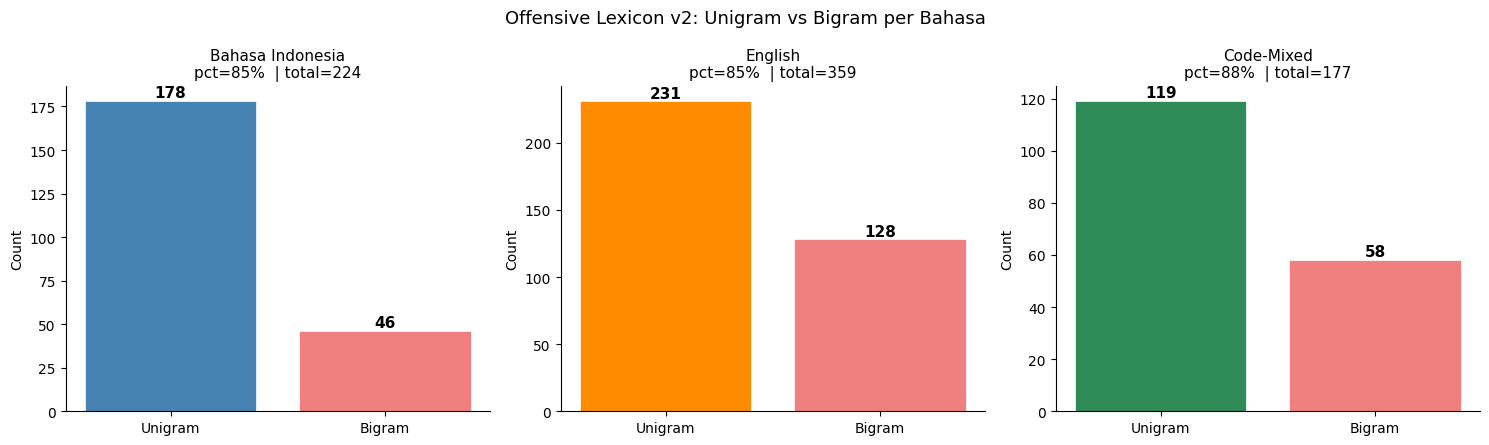

✅ Plot saved → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/lexicon_plot_v2.png


In [ ]:
# Simpan lexicon ke txt
lexicon_path = f'{BIO_DIR}/offensive_lexicon_v2.txt'
with open(lexicon_path, 'w', encoding='utf-8') as f:
    for entry in sorted(combined_lexicon):
        f.write(entry + '\n')
print(f'✅ Lexicon v2 saved → {lexicon_path}')
print(f'   Total entries: {len(combined_lexicon)}')
print(f'   Unigram      : {sum(1 for w in combined_lexicon if " " not in w)}')
print(f'   Bigram       : {sum(1 for w in combined_lexicon if " " in w)}')

# Simpan lang_stats ke JSON
lang_stats_path = f'{BIO_DIR}/lexicon_lang_stats_v2.json'
with open(lang_stats_path, 'w', encoding='utf-8') as f:
    json.dump(lang_stats, f, indent=2, ensure_ascii=False)
print(f'✅ lang_stats saved → {lang_stats_path}')
print('   (Gunakan angka ini di Bab 4: unigram/bigram per bahasa, cutoff score)')

# Plot distribusi unigram vs bigram per bahasa
def plot_lexicon_distribution(lang_stats: dict, lang_percentile: dict,
                               save_path: str):
    langs_available = [l for l in ['id', 'en', 'mixed'] if l in lang_stats]
    n = len(langs_available)
    if n == 0:
        print('⚠️  lang_stats kosong, skip plot.')
        return

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
    if n == 1:
        axes = [axes]

    colors       = {'id': 'steelblue', 'en': 'darkorange', 'mixed': 'seagreen'}
    lang_display = {'id': 'Bahasa Indonesia', 'en': 'English', 'mixed': 'Code-Mixed'}

    for ax, lang in zip(axes, langs_available):
        stats = lang_stats[lang]
        cats  = ['Unigram', 'Bigram']
        vals  = [stats['unigram'], stats['bigram']]
        bars  = ax.bar(cats, vals, color=[colors[lang], 'lightcoral'],
                       edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, str(v),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
        ax.set_title(
            f'{lang_display[lang]}\npct={lang_percentile[lang]}%  '
            f'| total={stats["total"]}',
            fontsize=11)
        ax.set_ylabel('Count')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('Offensive Lexicon v2: Unigram vs Bigram per Bahasa', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Plot saved → {save_path}')

plot_lexicon_distribution(
    lang_stats, LANG_PERCENTILE,
    save_path=f'{BIO_DIR}/lexicon_plot_v2.png'
)

## **Preprocessing Consistency Verification**

In [ ]:
def verify_preprocessing_consistency(lexicon: set) -> bool:
    test_cases = [
        ('Anjing!',         'anjing'),
        ('BANGSAT...',      'bangsat'),
        ("it's ok",        'its ok'),
        ('4nj1ng',          '4nj1ng'),
        ('hello world!',    'hello world'),
        ('otak  tempurung', 'otak tempurung'),
        ('anjiiiing',       'anjiing'),
        ('goobloook', 'gooblook'),
    ]
    all_ok = True
    print('Test cases eksplisit:')
    for raw, expected in test_cases:
        result = clean_for_tfidf(raw)
        ok     = result == expected
        status = '✅' if ok else '❌'
        print(f'  {status}  clean("{raw}") → "{result}" (expected: "{expected}")')
        if not ok:
            all_ok = False

    _unigrams = [w for w in lexicon if ' ' not in w]
    _bigrams  = [w for w in lexicon if ' ' in w]
    samples   = _unigrams[:5] + _bigrams[:5]

    print(f'\nStabilitas entri lexicon '
          f'(sample {len(_unigrams[:5])} unigram + {len(_bigrams[:5])} bigram):')
    for entry in samples:
        re_cleaned = clean_for_tfidf(entry)
        ok = re_cleaned == entry
        status = '✅' if ok else '❌'
        print(f'  {status}  "{entry}" → "{re_cleaned}"')
        if not ok:
            print(f'     ⚠️  Entry berubah setelah di-clean ulang!')
            all_ok = False

    print()
    if all_ok:
        print('✅ Preprocessing konsisten — clean_for_tfidf identik antara '
              'build lexicon dan labeling.')
    else:
        print('❌ ADA INKONSISTENSI — periksa clean_for_tfidf!')
    return all_ok

verify_preprocessing_consistency(combined_lexicon)

Test cases eksplisit:
  ✅  clean("Anjing!") → "anjing" (expected: "anjing")
  ✅  clean("BANGSAT...") → "bangsat" (expected: "bangsat")
  ✅  clean("it's ok") → "its ok" (expected: "its ok")
  ✅  clean("4nj1ng") → "4nj1ng" (expected: "4nj1ng")
  ✅  clean("hello world!") → "hello world" (expected: "hello world")
  ✅  clean("otak  tempurung") → "otak tempurung" (expected: "otak tempurung")
  ✅  clean("anjiiiing") → "anjiing" (expected: "anjiing")
  ✅  clean("goobloook") → "gooblook" (expected: "gooblook")

Stabilitas entri lexicon (sample 5 unigram + 5 bigram):
  ✅  "hopefully" → "hopefully"
  ✅  "vagina" → "vagina"
  ✅  "bolot" → "bolot"
  ✅  "busuk" → "busuk"
  ✅  "fat" → "fat"
  ✅  "bani onta" → "bani onta"
  ✅  "orang tionghoa" → "orang tionghoa"
  ✅  "an ugly" → "an ugly"
  ✅  "antek komunis" → "antek komunis"
  ✅  "kike on" → "kike on"

✅ Preprocessing konsisten — clean_for_tfidf identik antara build lexicon dan labeling.


True

## **Define `assign_bio_labels_v2` & `assign_bio_labels_nonhate`**

In [ ]:
NEGATION_ID = {'tidak','gak','ga','ngga','nggak','bukan','blm','belum'}
NEGATION_EN = {'not','no','never','without','neither','nor'}
NEGATION_ALL = NEGATION_ID | NEGATION_EN

def _apply_negation_filter(words: list, word_bio: list, window: int = 2) -> list:
    filtered = word_bio.copy()
    for i in range(1, len(words)):
        if filtered[i] in (1, 2):
            # Cek window kata ke belakang
            for k in range(max(0, i - window), i):
                if words[k].lower() in NEGATION_ALL:
                    filtered[i] = 0
                    j = i + 1
                    while j < len(words) and filtered[j] == 2:
                        filtered[j] = 0
                        j += 1
                    break
    return filtered

In [ ]:
import re as _re_bio

def _build_word_bio(text_norm: str, lexicon: set) -> list:
    words = text_norm.split()
    n_words = len(words)
    norm_words = [clean_for_tfidf(w) for w in words]
    word_bio = [0] * n_words

    # 1) Bigram dulu: prioritas span yang lebih panjang.
    i = 0
    while i < n_words - 1:
        w1 = norm_words[i]
        w2 = norm_words[i + 1]
        if not w1 or not w2:
            i += 1
            continue

        bigram = f'{w1} {w2}'
        if bigram in lexicon:
            if word_bio[i] == 0:
                word_bio[i] = 1  # B-TOX
            if word_bio[i + 1] == 0:
                word_bio[i + 1] = 2  # I-TOX
            i += 2
            continue
        i += 1

    # 2) Unigram untuk token yang masih O
    for i, tok in enumerate(norm_words):
        if word_bio[i] != 0:
            continue
        if not tok:
            continue
        if tok in lexicon:
            if i > 0 and word_bio[i - 1] in (1, 2):
                word_bio[i] = 2
            else:
                word_bio[i] = 1
    # Di akhir _build_word_bio, sebelum return:
    word_bio = _apply_negation_filter(words, word_bio)
    return word_bio

def assign_bio_labels_v2(text: str, lexicon: set, tokenizer,
                         max_length: int = 512) -> list:
    # Normalisasi whitespace agar identik dengan input tokenizer.
    text_norm = _re_bio.sub(r'\s+', ' ', str(text)).strip()
    words = text_norm.split()
    n_words = len(words)

    if n_words == 0:
        return [IGNORE_IDX] * max_length

    word_bio = _build_word_bio(text_norm, lexicon)

    enc = tokenizer(
        text_norm,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
        return_offsets_mapping=True,
    )
    attn_mask = enc['attention_mask'][0].tolist()
    offset_map = enc['offset_mapping'][0].tolist()

    # char -> word index mapping
    char_to_word = {}
    pos = 0
    for w_idx, w in enumerate(words):
        if w_idx > 0:
            char_to_word[pos - 1] = w_idx
        for c_off in range(len(w)):
            char_to_word[pos + c_off] = w_idx
        pos += len(w) + 1

    subtoken_bio = []
    seen_words = set()

    for mask_val, (start, end) in zip(attn_mask, offset_map):
        if mask_val == 0 or start == end:
            subtoken_bio.append(IGNORE_IDX)
            continue

        w_idx = char_to_word.get(start)
        if w_idx is None and start > 0:
            w_idx = char_to_word.get(start - 1)

        if w_idx is None or w_idx >= n_words:
            subtoken_bio.append(IGNORE_IDX)
            continue

        # Hanya label token pertama dari setiap kata.
        if w_idx in seen_words:
            subtoken_bio.append(IGNORE_IDX)
            continue

        subtoken_bio.append(word_bio[w_idx])
        seen_words.add(w_idx)

    if len(subtoken_bio) < max_length:
        subtoken_bio += [IGNORE_IDX] * (max_length - len(subtoken_bio))
    return subtoken_bio[:max_length]

def assign_bio_labels_nonhate(text: str, tokenizer,
                              max_length: int = 512) -> list:
    return [IGNORE_IDX] * max_length

def _preview_word_bio(text: str, lexicon: set, max_items: int = 24):
    text_norm = _re_bio.sub(r'\s+', ' ', str(text)).strip()
    words = text_norm.split()
    word_bio = _build_word_bio(text_norm, lexicon)
    pairs = []
    for w, lbl in zip(words, word_bio):
        pairs.append((w, ID2LABEL.get(lbl, str(lbl))))
        if len(pairs) >= max_items:
            break
    return pairs

print('── Sanity Test assign_bio_labels_v2 ────────────────────────────────')
_test_text = 'lo emang anjing bangsat bgt, dasar sampah'
_bio_test  = assign_bio_labels_v2(_test_text, combined_lexicon, tokenizer, MAX_LENGTH)
_enc_test  = tokenizer(_test_text, padding='max_length',
                       truncation=True, max_length=MAX_LENGTH)
_pairs = _preview_word_bio(_test_text, combined_lexicon, max_items=24)
if _pairs:
    _col_w = max(max(len(p[0]) for p in _pairs), 7)
    print(f'  TEXT  : {_test_text}')
    print(f'  TOKEN : {"  ".join(p[0].ljust(_col_w) for p in _pairs)}')
    print(f'  LABEL : {"  ".join(p[1].ljust(_col_w) for p in _pairs)}')
    n_btox = sum(1 for _, l in _pairs if l == 'B-TOX')
    n_itox = sum(1 for _, l in _pairs if l == 'I-TOX')
    print(f'\n  B-TOX: {n_btox} | I-TOX: {n_itox} | (word-level preview)')
else:
    print('  ⚠️  Tidak ada token aktif — lexicon mungkin belum mengcover kata-kata ini.')
print('─' * 65)

── Sanity Test assign_bio_labels_v2 ────────────────────────────────
  TEXT  : lo emang anjing bangsat bgt, dasar sampah
  TOKEN : lo       emang    anjing   bangsat  bgt,     dasar    sampah 
  LABEL : O        O        B-TOX    I-TOX    O        B-TOX    O      

  B-TOX: 2 | I-TOX: 1 | (word-level preview)
─────────────────────────────────────────────────────────────────


## **Helper Functions — `export_bio_npy` & `analyze_bio_coverage`**

In [ ]:
def export_bio_npy(df_bio: pd.DataFrame, split_name: str,
                    bio_dir: str, tokenizer, max_length: int = 512):
    texts           = df_bio['text'].tolist()
    input_ids_list  = []
    attn_mask_list  = []

    for text in tqdm(texts, desc=f'Tokenizing [{split_name}]'):
        text_norm = re.sub(r'\s+', ' ', str(text)).strip()
        enc = tokenizer(
            text_norm,
            padding        = 'max_length',
            truncation     = True,
            max_length     = max_length,
            return_tensors = 'pt',
        )
        input_ids_list.append(enc['input_ids'].squeeze(0).numpy().astype('int32'))
        attn_mask_list.append(enc['attention_mask'].squeeze(0).numpy().astype('int32'))

    ids_arr  = np.array(input_ids_list, dtype=np.int32)
    mask_arr = np.array(attn_mask_list, dtype=np.int32)

    ids_path  = f'{bio_dir}/{split_name}_input_ids.npy'
    mask_path = f'{bio_dir}/{split_name}_attn_mask.npy'

    np.save(ids_path,  ids_arr)
    np.save(mask_path, mask_arr)

    # export bio_labels sebagai NPY
    bio_arr  = np.array(df_bio['bio_labels'].tolist(), dtype=np.int32)
    bio_path = f'{bio_dir}/{split_name}_bio_labels.npy'
    np.save(bio_path, bio_arr)

    print(f'✅ [{split_name}] NPY exported:')
    print(f'   input_ids  → {ids_path}   shape={ids_arr.shape}  dtype={ids_arr.dtype}')
    print(f'   attn_mask  → {mask_path}  shape={mask_arr.shape} dtype={mask_arr.dtype}')
    print(f'   bio_labels → {bio_path}   shape={bio_arr.shape}  dtype={bio_arr.dtype}')

# BIO Coverage Analysis
def analyze_bio_coverage(df: pd.DataFrame, split_name: str) -> dict:
    hate_df = df[df['label'] == 1].copy()
    if len(hate_df) == 0:
        print(f'⚠️  [{split_name}] Tidak ada sampel hate.')
        return {}

    def parse_bio(val):
        if isinstance(val, str):
            return json.loads(val)
        return list(val)

    def active_count(seq):
        return sum(1 for x in seq if x not in (IGNORE_IDX, 0))

    hate_df['bio_parsed'] = hate_df['bio_labels'].apply(parse_bio)
    hate_df['active_cnt']  = hate_df['bio_parsed'].apply(active_count)
    hate_df['all_O']      = hate_df['active_cnt'].apply(lambda x: x == 0)

    print(f"\n{'═'*76}")
    print(f' BIO COVERAGE ANALYSIS — {split_name.upper()} SET')
    print(f"{'═'*76}")
    print(f" {'Bahasa':<12} {'Hate N':>8} {'Empty BIO':>10} {'Empty%':>8} {'Coverage%':>10} "
          f"{'MeanTok':>9} {'Median':>8}")
    print(f" {'─'*12} {'─'*8} {'─'*10} {'─'*8} {'─'*10} {'─'*9} {'─'*8}")

    result = {}
    for lang in ['id', 'en', 'mixed']:
        sub = hate_df[hate_df['language'] == lang]
        n   = len(sub)
        if n == 0:
            continue

        n_empty = int(sub['all_O'].sum())
        pct_empty = n_empty / n * 100
        pct_cov   = 100 - pct_empty
        active_nonzero = sub.loc[sub['active_cnt'] > 0, 'active_cnt']
        mean_active = float(active_nonzero.mean()) if len(active_nonzero) else 0.0
        median_active = float(active_nonzero.median()) if len(active_nonzero) else 0.0

        print(f' {lang:<12} {n:>8,} {n_empty:>10,} {pct_empty:>7.1f}% {pct_cov:>9.1f}% '
              f'{mean_active:>9.2f} {median_active:>8.2f}')
        result[lang] = {
            'n_hate': int(n),
            'n_empty': int(n_empty),
            'empty_pct': round(pct_empty, 2),
            'coverage_pct': round(pct_cov, 2),
            'theoretical_ub': round(pct_cov, 2),
            'mean_active_tokens': round(mean_active, 2),
            'median_active_tokens': round(median_active, 2),
        }

    print(f"{'═'*76}")
    print(" Interpretasi:")
    print(" - Empty% = sampel hate yang belum mendapat token toxic dari lexicon v2")
    print(" - Coverage% = proporsi sampel hate yang punya minimal satu token aktif")
    print(" - MeanTok/Median = panjang span aktif rata-rata pada sampel yang ter-cover")
    return result

print('✅ Helper functions siap: export_bio_npy & analyze_bio_coverage')

✅ Helper functions siap: export_bio_npy & analyze_bio_coverage


## **Helper — `process_split`: Labeling + Verifikasi Kolom + Simpan CSV**

In [ ]:
VALID_LANGUAGES   = {'id', 'en', 'mixed'}
REQUIRED_OUT_COLS = ['text', 'label', 'language', 'bio_labels',
                     'has_slang', 'has_abbrev']

def process_split(df_split: pd.DataFrame, split_name: str,
                   lexicon: set, tokenizer,
                   bio_dir: str, max_length: int = 512) -> tuple:
    print(f"\n{'━'*65}")
    print(f' PROSES SPLIT: {split_name.upper()}   ({len(df_split):,} baris)')
    print(f"{'━'*65}")

    df = df_split.copy()

    # Validasi language
    invalid_langs = set(df['language'].unique()) - VALID_LANGUAGES
    if invalid_langs:
        print(f'  ⚠️  Language tidak valid: {invalid_langs} → fallback ke "mixed"')
        df['language'] = df['language'].apply(
            lambda l: l if l in VALID_LANGUAGES else 'mixed'
        )

    # Assign BIO labels
    bio_col = []
    errors  = 0
    for idx, row in tqdm(df.iterrows(), total=len(df),
                          desc=f'BIO [{split_name}]'):
        try:
            if int(row['label']) == 1:
                bio = assign_bio_labels_v2(
                    text=str(row['text']),
                    lexicon=lexicon,
                    tokenizer=tokenizer,
                    max_length=max_length,
                )
            else:
                bio = assign_bio_labels_nonhate(
                    text=str(row['text']),
                    tokenizer=tokenizer,
                    max_length=max_length,
                )
            assert len(bio) == max_length, (
                f'BIO length mismatch di idx={idx}: '
                f'got {len(bio)}, expected {max_length}'
            )
            bio_col.append(bio)
        except Exception as e:
            print(f'  ERROR di idx={idx}: {e}')
            bio_col.append([IGNORE_IDX] * max_length)
            errors += 1

    if errors > 0:
        print(f'  ⚠️  {errors} baris menggunakan BIO fallback (semua IGNORE_IDX)')

    df['bio_labels'] = bio_col

    # Verifikasi kolom output
    missing_cols = [c for c in REQUIRED_OUT_COLS if c not in df.columns]
    if missing_cols:
        print(f'  ⚠️  Kolom berikut tidak ada, ditambahkan default 0: {missing_cols}')
        for c in missing_cols:
            df[c] = 0
    else:
        print(f'  ✅ Semua kolom output tersedia: {REQUIRED_OUT_COLS}')

    # Simpan CSV
    df_save = df.copy()
    df_save['bio_labels'] = df_save['bio_labels'].apply(json.dumps)
    out_path = f'{bio_dir}/{split_name}_bio.csv'
    df_save.to_csv(out_path, index=False)
    size_mb = os.path.getsize(out_path) / 1024 / 1024
    print(f'  ✅ CSV saved → {out_path}  ({len(df):,} rows, {size_mb:.1f} MB)')

    # Export NPY
    export_bio_npy(df, split_name, bio_dir, tokenizer, max_length)

    # BIO Coverage Analysis
    coverage = analyze_bio_coverage(df, split_name)

    return df, coverage

print('✅ process_split siap digunakan.')

✅ process_split siap digunakan.


## **Split TRAIN Process**

In [ ]:
df_train_bio, coverage_train = process_split(
    df_train, 'train', combined_lexicon, tokenizer, BIO_DIR, MAX_LENGTH
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PROSES SPLIT: TRAIN   (28,000 baris)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


BIO [train]:   0%|          | 0/28000 [00:00<?, ?it/s]

  ✅ Semua kolom output tersedia: ['text', 'label', 'language', 'bio_labels', 'has_slang', 'has_abbrev']
  ✅ CSV saved → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/train_bio.csv  (28,000 rows, 85.2 MB)


Tokenizing [train]:   0%|          | 0/28000 [00:00<?, ?it/s]

✅ [train] NPY exported:
   input_ids  → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/train_input_ids.npy   shape=(28000, 512)  dtype=int32
   attn_mask  → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/train_attn_mask.npy  shape=(28000, 512) dtype=int32
   bio_labels → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/train_bio_labels.npy   shape=(28000, 512)  dtype=int32

════════════════════════════════════════════════════════════════════════════
 BIO COVERAGE ANALYSIS — TRAIN SET
════════════════════════════════════════════════════════════════════════════
 Bahasa         Hate N  Empty BIO   Empty%  Coverage%   MeanTok   Median
 ──────────── ──────── ────────── ──────── ────────── ───────── ────────
 id              4,057        274     6.8%      93.2%      3.12     3.00
 en              4,200        253     6.0%      94.0%      4.47     3.00
 mixed           5,744        433     7.5%      92.5%      3.48     3.00
════════════════════════════════════════════════════════

## **Split VAL Process**

In [ ]:
df_val_bio, coverage_val = process_split(
    df_val, 'val', combined_lexicon, tokenizer, BIO_DIR, MAX_LENGTH
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PROSES SPLIT: VAL   (6,000 baris)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


BIO [val]:   0%|          | 0/6000 [00:00<?, ?it/s]

  ✅ Semua kolom output tersedia: ['text', 'label', 'language', 'bio_labels', 'has_slang', 'has_abbrev']
  ✅ CSV saved → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/val_bio.csv  (6,000 rows, 18.3 MB)


Tokenizing [val]:   0%|          | 0/6000 [00:00<?, ?it/s]

✅ [val] NPY exported:
   input_ids  → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/val_input_ids.npy   shape=(6000, 512)  dtype=int32
   attn_mask  → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/val_attn_mask.npy  shape=(6000, 512) dtype=int32
   bio_labels → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/val_bio_labels.npy   shape=(6000, 512)  dtype=int32

════════════════════════════════════════════════════════════════════════════
 BIO COVERAGE ANALYSIS — VAL SET
════════════════════════════════════════════════════════════════════════════
 Bahasa         Hate N  Empty BIO   Empty%  Coverage%   MeanTok   Median
 ──────────── ──────── ────────── ──────── ────────── ───────── ────────
 id                869         76     8.7%      91.3%      3.17     3.00
 en                900         49     5.4%      94.6%      4.24     3.00
 mixed           1,231        120     9.7%      90.3%      3.57     3.00
═════════════════════════════════════════════════════════════════════

## **Split TEST Process**

In [ ]:
df_test_bio, coverage_test = process_split(
    df_test, 'test', combined_lexicon, tokenizer, BIO_DIR, MAX_LENGTH
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PROSES SPLIT: TEST   (6,000 baris)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


BIO [test]:   0%|          | 0/6000 [00:00<?, ?it/s]

  ✅ Semua kolom output tersedia: ['text', 'label', 'language', 'bio_labels', 'has_slang', 'has_abbrev']
  ✅ CSV saved → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/test_bio.csv  (6,000 rows, 18.3 MB)


Tokenizing [test]:   0%|          | 0/6000 [00:00<?, ?it/s]

✅ [test] NPY exported:
   input_ids  → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/test_input_ids.npy   shape=(6000, 512)  dtype=int32
   attn_mask  → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/test_attn_mask.npy  shape=(6000, 512) dtype=int32
   bio_labels → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/test_bio_labels.npy   shape=(6000, 512)  dtype=int32

════════════════════════════════════════════════════════════════════════════
 BIO COVERAGE ANALYSIS — TEST SET
════════════════════════════════════════════════════════════════════════════
 Bahasa         Hate N  Empty BIO   Empty%  Coverage%   MeanTok   Median
 ──────────── ──────── ────────── ──────── ────────── ───────── ────────
 id                868         64     7.4%      92.6%      2.92     2.00
 en                900         53     5.9%      94.1%      4.17     3.00
 mixed           1,231         89     7.2%      92.8%      3.61     3.00
════════════════════════════════════════════════════════════════

In [ ]:
def analyze_bio_label_distribution(df_bio: pd.DataFrame, split_name: str) -> dict:
    hate_df = df_bio[df_bio['label'] == 1].copy()

    def _parse(val):
        return json.loads(val) if isinstance(val, str) else list(val)

    def _active_count(seq):
        """Hitung HANYA token B-TOX (1) dan I-TOX (2). O dan IGNORE tidak dihitung."""
        return sum(1 for x in seq if x not in (IGNORE_IDX, 0))

    hate_df['bio_parsed'] = hate_df['bio_labels'].apply(_parse)
    hate_df['active_cnt']  = hate_df['bio_parsed'].apply(_active_count)

    flat_labels = list(itertools.chain.from_iterable(
        _parse(v) for v in hate_df['bio_labels']
    ))
    active = [l for l in flat_labels if l != IGNORE_IDX]
    total  = len(active)

    print(f"\n{'═'*72}")
    print(f' BIO LABEL DISTRIBUTION — {split_name.upper()} (Hate only)')
    print(f"{'═'*72}")
    print(f" {'Label':<12} {'Count':>10} {'Persen':>10}")
    print(f" {'─'*12} {'─'*10} {'─'*10}")

    result = {}
    for lid, name in [(0, 'O'), (1, 'B-TOX'), (2, 'I-TOX')]:
        n   = sum(1 for l in active if l == lid)
        pct = n / total * 100 if total > 0 else 0
        print(f' {name:<12} {n:>10,} {pct:>9.2f}%')
        result[name] = {'count': int(n), 'pct': round(pct, 2)}

    n_tox   = result['B-TOX']['count'] + result['I-TOX']['count']
    pct_tox = n_tox / total * 100 if total > 0 else 0

    # _active_count sekarang hanya menghitung B-TOX + I-TOX per sampel
    active_samples    = hate_df[hate_df['active_cnt'] > 0]
    mean_active       = float(active_samples['active_cnt'].mean())   if len(active_samples) else 0.0
    median_active     = float(active_samples['active_cnt'].median()) if len(active_samples) else 0.0

    print(f' {"─"*12} {"─"*10} {"─"*10}')
    print(f' {"TOX (total)":<12} {n_tox:>10,} {pct_tox:>9.2f}%')
    print(f' {"ACTIVE SAMP":<12} {len(active_samples):>10,} '
          f'{100 * len(active_samples) / len(hate_df):>9.2f}%')
    print(f' {"MEAN TOX":<12} {mean_active:>10.2f}   ← rata-rata token toxic per sampel hate ter-cover')
    print(f' {"MEDIAN TOX":<12} {median_active:>10.2f}')
    print(f"{'═'*72}")
    print(' Interpretasi: ACTIVE SAMP = % sampel hate yang punya ≥1 token toxic ter-label.')
    print('               MEAN/MEDIAN TOX = rata-rata jumlah token B-TOX+I-TOX per sampel.')

    result['TOX_total'] = {'count': int(n_tox), 'pct': round(pct_tox, 2)}
    result['active_samples'] = {
        'count': int(len(active_samples)),
        'pct': round(100 * len(active_samples) / len(hate_df), 2),
    }
    result['mean_active_tokens']   = round(mean_active, 2)
    result['median_active_tokens'] = round(median_active, 2)
    return result


dist_train = analyze_bio_label_distribution(df_train_bio, 'train')
dist_val   = analyze_bio_label_distribution(df_val_bio,   'val')
dist_test  = analyze_bio_label_distribution(df_test_bio,  'test')

dist_all = {'train': dist_train, 'val': dist_val, 'test': dist_test}
with open(f'{BIO_DIR}/bio_label_distribution_v2.json', 'w') as f:
    json.dump(dist_all, f, indent=2)
print(f'\n✅ Saved → {BIO_DIR}/bio_label_distribution_v2.json')
print('📌 Gunakan ACTIVE SAMP% dan MEAN TOX di Bab 4 sebagai upper bound coverage lexicon v2.')


════════════════════════════════════════════════════════════════════════
 BIO LABEL DISTRIBUTION — TRAIN (Hate only)
════════════════════════════════════════════════════════════════════════
 Label             Count     Persen
 ──────────── ────────── ──────────
 O               223,258     82.32%
 B-TOX            34,767     12.82%
 I-TOX            13,180      4.86%
 ──────────── ────────── ──────────
 TOX (total)      47,947     17.68%
 ACTIVE SAMP      13,041     93.14%
 MEAN TOX           3.68   ← rata-rata token toxic per sampel hate ter-cover
 MEDIAN TOX         3.00
════════════════════════════════════════════════════════════════════════
 Interpretasi: ACTIVE SAMP = % sampel hate yang punya ≥1 token toxic ter-label.
               MEAN/MEDIAN TOX = rata-rata jumlah token B-TOX+I-TOX per sampel.

════════════════════════════════════════════════════════════════════════
 BIO LABEL DISTRIBUTION — VAL (Hate only)
══════════════════════════════════════════════════════════════════════

## **Save `bio_coverage_analysis_v2.json`**

In [ ]:
all_coverage = {
    'train': coverage_train,
    'val':   coverage_val,
    'test':  coverage_test,
}

coverage_path = f'{BIO_DIR}/bio_coverage_analysis_v2.json'
with open(coverage_path, 'w', encoding='utf-8') as f:
    json.dump(all_coverage, f, indent=2, ensure_ascii=False)

print(f'✅ Saved → {coverage_path}')
print('\n📌 Gunakan angka ini di Bab 4 untuk upper bound Span-F1 dan sanity check coverage:')
for split, cov in all_coverage.items():
    if not cov:
        continue
    print(f'  [{split.upper()}]')
    for lang, stats in cov.items():
        print(f'    {lang}: empty={stats["empty_pct"]}%  '
              f'coverage={stats["coverage_pct"]}%  '
              f'mean_active={stats["mean_active_tokens"]}  '
              f'UB={stats["theoretical_ub"]}%')

✅ Saved → /content/drive/MyDrive/Colab Datasets/BIO Splits v2/bio_coverage_analysis_v2.json

📌 Gunakan angka ini di Bab 4 untuk upper bound Span-F1 dan sanity check coverage:
  [TRAIN]
    id: empty=6.75%  coverage=93.25%  mean_active=3.12  UB=93.25%
    en: empty=6.02%  coverage=93.98%  mean_active=4.47  UB=93.98%
    mixed: empty=7.54%  coverage=92.46%  mean_active=3.48  UB=92.46%
  [VAL]
    id: empty=8.75%  coverage=91.25%  mean_active=3.17  UB=91.25%
    en: empty=5.44%  coverage=94.56%  mean_active=4.24  UB=94.56%
    mixed: empty=9.75%  coverage=90.25%  mean_active=3.57  UB=90.25%
  [TEST]
    id: empty=7.37%  coverage=92.63%  mean_active=2.92  UB=92.63%
    en: empty=5.89%  coverage=94.11%  mean_active=4.17  UB=94.11%
    mixed: empty=7.23%  coverage=92.77%  mean_active=3.61  UB=92.77%


## **Preview BIO Examples (Hate & Non-Hate)**

In [ ]:
def show_bio_preview(row: pd.Series, tokenizer,
                     max_tokens: int = 20) -> None:
    text     = str(row['text'])
    language = str(row['language'])
    label    = int(row['label'])

    bio = row['bio_labels']
    if isinstance(bio, str):
        bio = json.loads(bio)

    W = 86
    print('═' * W)
    print(f'  TEXT  : {text[:110]}')
    print(f'  LANG  : {language}   │   LABEL: {label} '
          f'({"HATE" if label == 1 else "NON-HATE"})')
    print('─' * W)

    if label == 0:
        print('  BIO   : non-hate → token-level loss di-mask seluruhnya')
    else:
        pairs = _preview_word_bio(text, combined_lexicon, max_items=max_tokens)
        if pairs:
            col_w = max(max(len(p[0]) for p in pairs), 7)
            print(f'  WORD  : {"  ".join(p[0].ljust(col_w) for p in pairs)}')
            print(f'  LABEL : {"  ".join(p[1].ljust(col_w) for p in pairs)}')

            active_idx = [i for i, (_, lbl) in enumerate(pairs) if lbl in ('B-TOX', 'I-TOX')]
            if active_idx:
                active_words = [pairs[i][0] for i in active_idx]
                print(f'  SPAN  : {" ".join(active_words)}')
            else:
                print('  SPAN  : (tidak ada token aktif di preview ini)')
        else:
            print('  BIO   : (tidak ada token aktif di lexicon v2)')
    print('═' * W)
    print()


# HATE examples (5 dari train)
print('━' * 86)
print('  PREVIEW — HATE (label = 1)   [5 sampel dari train]')
print('━' * 86)
print()
hate_sample = df_train_bio[df_train_bio['label'] == 1].sample(
    10, random_state=42
)
for _, row in hate_sample.iterrows():
    show_bio_preview(row, tokenizer)

# NON-HATE examples (2 dari train)
print('━' * 86)
print('  PREVIEW — NON-HATE (label = 0)   [2 sampel dari train]')
print('━' * 86)
print()
nonhate_sample = df_train_bio[df_train_bio['label'] == 0].sample(
    5, random_state=42
)
for _, row in nonhate_sample.iterrows():
    show_bio_preview(row, tokenizer)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREVIEW — HATE (label = 1)   [5 sampel dari train]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

══════════════════════════════════════════════════════════════════════════════════════
  TEXT  : orang ini akan nyunsep bersama jokowi . url
  LANG  : id   │   LABEL: 1 (HATE)
──────────────────────────────────────────────────────────────────────────────────────
  WORD  : orang    ini      akan     nyunsep  bersama  jokowi   .        url    
  LABEL : B-TOX    O        O        O        O        B-TOX    O        O      
  SPAN  : orang jokowi
══════════════════════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════════════════════
  TEXT  : when that rag head nadiya won the great british bake off the media described her as moslem but the child rapis
  LANG  : en   │   LABEL: 1 

## **Final Summary & Validation**

In [ ]:
print('\n' + '═'*70)
print('  NB02v2 — SUMMARY AKHIR')
print('═'*70)

# 1. Lexicon stats
n_unigram_total = sum(1 for w in combined_lexicon if ' ' not in w)
n_bigram_total  = sum(1 for w in combined_lexicon if ' ' in w)
print(f'\n📚 LEXICON v2:')
print(f'   Total entries  : {len(combined_lexicon):,}')
print(f'   Unigram        : {n_unigram_total:,}')
print(f'   Bigram (baru!) : {n_bigram_total:,}')

# 2. Dataset sizes
print(f'\n📊 DATASET SIZES:')
print(f'   Train : {len(df_train_bio):,} baris')
print(f'   Val   : {len(df_val_bio):,} baris')
print(f'   Test  : {len(df_test_bio):,} baris')

# 3. File check
expected_files = [
    'train_bio.csv', 'val_bio.csv', 'test_bio.csv',
    'train_input_ids.npy', 'train_attn_mask.npy',
    'val_input_ids.npy',   'val_attn_mask.npy',
    'test_input_ids.npy',  'test_attn_mask.npy',
    'train_bio_labels.npy',
    'val_bio_labels.npy',
    'test_bio_labels.npy',
    'offensive_lexicon_v2.txt',
    'lexicon_lang_stats_v2.json',
    'lexicon_plot_v2.png',
    'bio_coverage_analysis_v2.json',
    'bio_coverage_comparison_v1_v2.json',
]
print(f'\n📁 FILE CHECK — {BIO_DIR}:')
all_files_ok = True
for fname in expected_files:
    fpath = f'{BIO_DIR}/{fname}'
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'   ✅ {fname:<45} ({size_kb:>8.1f} KB)')
    else:
        print(f'   ❌ {fname:<45} MISSING!')
        all_files_ok = False

# 4. Kolom CSV check
print(f'\n🔍 KOLOM CSV CHECK:')
for split_name, df_bio in [('train', df_train_bio), ('val', df_val_bio),
                             ('test', df_test_bio)]:
    missing = [c for c in REQUIRED_OUT_COLS if c not in df_bio.columns]
    if missing:
        print(f'   ❌ [{split_name}] Missing: {missing}')
    else:
        print(f'   ✅ [{split_name}] Semua kolom ada: {REQUIRED_OUT_COLS}')

# 5. NPY shape check
print(f'\n🔢 NPY SHAPE CHECK (harus (n_samples, {MAX_LENGTH}), dtype=int32):')
for split_name, expected_n in [('train', len(df_train_bio)),
                               ('val',   len(df_val_bio)),
                               ('test',  len(df_test_bio))]:
    for arr_type in ['input_ids', 'attn_mask', 'bio_labels']:
        fpath = f'{BIO_DIR}/{split_name}_{arr_type}.npy'
        if os.path.exists(fpath):
            arr = np.load(fpath)
            ok  = (arr.shape == (expected_n, MAX_LENGTH) and
                   arr.dtype in (np.int32, np.int64))
            status = '✅' if ok else '❌'
            print(f'   {status} {split_name}_{arr_type}: '
                  f'shape={arr.shape} dtype={arr.dtype}')
        else:
            print(f'   ❌ {split_name}_{arr_type}.npy MISSING!')

# 6. BIO coverage summary
print(f'\n📈 BIO COVERAGE SUMMARY (v2):')
for split, cov in all_coverage.items():
    if not cov:
        continue
    print(f'  [{split.upper()}]')
    for lang, stats in cov.items():
        print(f'    {lang:>6}: hate_n={stats["n_hate"]:>5,}  '
              f'empty={stats["empty_pct"]:>5.1f}%  '
              f'coverage={stats.get("coverage_pct", 100 - stats["empty_pct"]):>5.1f}%  '
              f'mean_active={stats.get("mean_active_tokens", 0):>5.2f}  '
              f'UB_teoritis={stats["theoretical_ub"]:>5.1f}%')

# Final verdict
print()
print('═'*70)
if all_files_ok:
    print('  ✅ NB02v2 SELESAI — Semua file tersimpan di BIO Splits v2/')
    print('  ▶️  Lanjut ke NB03v2 (BLOOM MTL Training dengan BIO ground truth v2)')
else:
    print('  ⚠️  Ada file yang MISSING — periksa error di atas!')
print('═'*70)


══════════════════════════════════════════════════════════════════════
  NB02v2 — SUMMARY AKHIR
══════════════════════════════════════════════════════════════════════

📚 LEXICON v2:
   Total entries  : 736
   Unigram        : 506
   Bigram (baru!) : 230

📊 DATASET SIZES:
   Train : 28,000 baris
   Val   : 6,000 baris
   Test  : 6,000 baris

📁 FILE CHECK — /content/drive/MyDrive/Colab Datasets/BIO Splits v2:
   ✅ train_bio.csv                                 ( 87290.2 KB)
   ✅ val_bio.csv                                   ( 18701.4 KB)
   ✅ test_bio.csv                                  ( 18709.8 KB)
   ✅ train_input_ids.npy                           ( 56000.1 KB)
   ✅ train_attn_mask.npy                           ( 56000.1 KB)
   ✅ val_input_ids.npy                             ( 12000.1 KB)
   ✅ val_attn_mask.npy                             ( 12000.1 KB)
   ✅ test_input_ids.npy                            ( 12000.1 KB)
   ✅ test_attn_mask.npy                            ( 12000.1 KB)
   